In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import ast
from sklearn.metrics import accuracy_score
import copy
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, f1_score,average_precision_score)
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import SplineTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error,root_mean_squared_error
from scipy.stats import spearmanr
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance

# Load

In [2]:
path = "D:\\Research"

In [3]:
newness = np.load(f"{path}\\Creativity_Artnet\\Datasets\\newness_2024.npy",allow_pickle=True)
surprise = np.load(f"{path}\\Creativity_Artnet\\Datasets\\surprise_2024.npy",allow_pickle=True)
value = np.load(f"{path}\\Creativity_Artnet\\Datasets\\value_2024.npy",allow_pickle=True)

In [4]:
surprise = surprise.squeeze()

In [5]:
BASELINE_YEAR=1600

In [87]:
gold_set_70 = pd.read_excel(f"{path}\\Creativity_Artnet\\Codes\\Evaluation\\golden_set_move_creative_70.xlsx")
creative_70_origin = np.load(f"{path}\\Creativity_Artnet\\Datasets\\creativity_70_full_prob.npy",allow_pickle=True)
artnet_2024 = pd.read_excel(f"{path}\\Creativity_Artnet\\Datasets\\ArtNet\\Artnet_Europe_2024_merged.xlsx")
merged_df_origin = pd.merge(gold_set_70, artnet_2024[["artwork id","artist id","year born","workyear modifier","price","artist",'est lo usd','est hi usd', 'sale price usd']], on='artwork id', how='left')

In [88]:
newness_df = np.zeros(merged_df_origin.shape[0], dtype=object)
surprise_df = np.zeros(merged_df_origin.shape[0], dtype=object)
value_df = np.zeros(merged_df_origin.shape[0], dtype=object)
for i in range(merged_df_origin.shape[0]):
    row_index = merged_df_origin.index[i]
    newness_df[i] =newness[row_index]
    surprise_df[i] =surprise[row_index]
    value_df[i] = value[row_index]

The inverse of Sigmoid is Logit.

In [89]:
def logit(p, epsilon=1e-10):
    # Clip p to avoid log(0) or log(1/0)
    p = np.clip(p, epsilon, 1 - epsilon)
    return np.log(p / (1 - p))

In [90]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [91]:
def topk_hit_rate_curve(y_true, y_pred, rates):
    hit_rates = []
    n = len(y_true)

    for rate in rates:
        k = int(n * rate)
        if k == 0:
            hit_rates.append(np.nan)
            continue

        true_top_idx = np.argsort(y_true)[-k:]
        pred_top_idx = np.argsort(y_pred)[-k:]

        hit_rate = len(set(true_top_idx) & set(pred_top_idx)) / k
        hit_rates.append(hit_rate)

    return hit_rates

In [92]:
def kl_divergence(p, q, eps=1e-12):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    # Normalize (important if they are not exact probabilities)
    p = p / p.sum()
    q = q / q.sum()

    # Avoid log(0)
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)

    return np.sum(p * np.log(p / q))

# Basic

In [93]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error,root_mean_squared_error
from scipy.stats import spearmanr
from sklearn.model_selection import cross_validate
from sklearn.metrics import recall_score
import sklearn

In [118]:
artist_list = ["Pablo Picasso","Pierre-Auguste Renoir","Käthe Kollwitz"]
keep_list = merged_df_origin["artist"].isin(artist_list)
remove_list = [x for x in keep_list.index if not keep_list[x]]

In [119]:
merged_df = merged_df_origin[keep_list]

In [120]:
creative_70 = creative_70_origin[keep_list]

In [121]:
kls = []
jss = []
wds = []
epsilon=1e-6
for i in range(len(remove_list)+1):
    print(f"merge_df shape {merged_df.shape[0]}")
    newness_df = np.zeros(merged_df.shape[0], dtype=object)
    surprise_df = np.zeros(merged_df.shape[0], dtype=object)
    value_df = np.zeros(merged_df.shape[0], dtype=object)

    for j in range(merged_df.shape[0]):
        row_index = merged_df.index[j]
        newness_df[j] =newness[row_index]
        surprise_df[j] =surprise[row_index]
        value_df[j] = value[row_index]
    newness_min=np.min(newness_df)
    newness_max = np.max(newness_df)
    newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
    surprise_min=np.min(surprise_df)
    surprise_max = np.max(surprise_df)
    surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
    value_min=np.min(value_df)
    value_max = np.max(value_df)
    value_normalized=(value_df - value_min)/(value_max-value_min)
    creativity_min = np.min(creative_70)
    creativity_max =np.max(creative_70)
    creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)
    
    y = logit(creativity_normalized,epsilon)
    X = np.column_stack([
        np.log((newness_normalized+epsilon).astype(float)),
        np.log((surprise_normalized+epsilon).astype(float)),
        np.log((value_normalized+epsilon).astype(float))
    ])
    X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=24)

    model = LinearRegression()
    model.fit(X_train, y_train)

    true_label = sigmoid(y_test)
    pred_y = sigmoid(model.predict(X_test))

    kl = kl_divergence(true_label, pred_y)
    # print("Test KL:", kl )
    js = jensenshannon(true_label, pred_y)**2
    # print("Test JS:", js )
    wd = wasserstein_distance(true_label, pred_y)
    # print("Test Wasserstein Distance :", wd )
    
    
    kls.append(kl)
    jss.append(js)
    wds.append(wd)
    if i < len(remove_list):
        keep_list[remove_list[i]] = True
        creative_70 = creative_70_origin[keep_list]
        merged_df = merged_df_origin[keep_list]
    

merge_df shape 1862
merge_df shape 1863
merge_df shape 1864
merge_df shape 1865
merge_df shape 1866
merge_df shape 1867
merge_df shape 1868
merge_df shape 1869
merge_df shape 1870
merge_df shape 1871
merge_df shape 1872
merge_df shape 1873
merge_df shape 1874


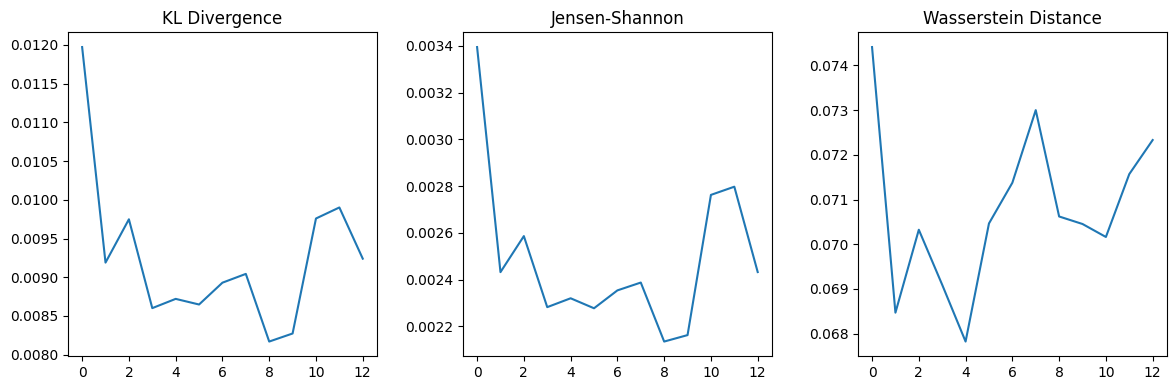

In [123]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(x, kls)
axes[0].set_title("KL Divergence")

axes[1].plot(x, jss)
axes[1].set_title("Jensen-Shannon")

axes[2].plot(x, wds)
axes[2].set_title("Wasserstein Distance")

plt.tight_layout()
plt.show()